# Fall Detection — Preprocessing Pipeline v3
**Sensor:** CHEST (ID=1, AccType=0) | **Dataset:** UMA ADL FALL

### Aktivitas yang diketahui dari dataset:
```
ADL_Walking, ADL_Jogging, ADL_Sitting, ADL_LyingDown,
ADL_Hopping, ADL_Bending, ADL_GoUpstairs, ADL_GoDownstairs,
ADL_Aplausing, ADL_HandsUp, ADL_MakingACall, ADL_OpeningDoor,
Fall_backwardFall, Fall_forwardFall, Fall_lateralFall
```
### Target label kita: **duduk, jalan, tidur, jatuh**
*(aktivitas lain di-skip)*

## STEP 0 — Import

In [ ]:
!pip install scipy -q
import os, re, zipfile, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import LabelEncoder
from collections import Counter
print('Import OK')

Import OK


## STEP 1 — Download & Extract

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Copy dataset from Google Drive
# Make sure the path is correct for your Google Drive
SOURCE_PATH = '/content/drive/MyDrive/uma_fall_data/UMAFall_Dataset_corrected_version.zip'
DEST_PATH = 'UMA_ADL_FALL_Dataset.zip'

!cp "{SOURCE_PATH}" "{DEST_PATH}"

print('✅ Dataset copied from Google Drive')
print(f'File size: {os.path.getsize(DEST_PATH) / (1024*1024):.2f} MB')

Mounted at /content/drive
✅ Dataset copied from Google Drive
File size: 74.85 MB


In [ ]:
EXTRACT_DIR = '/content/UMA_Dataset'
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile('UMA_ADL_FALL_Dataset.zip', 'r') as z:
    z.extractall(EXTRACT_DIR)

# Extract zip bersarang secara rekursif
changed = True
while changed:
    changed = False
    for root, dirs, files in os.walk(EXTRACT_DIR):
        for f in files:
            if f.endswith('.zip'):
                zp = os.path.join(root, f)
                out = zp.replace('.zip', '')
                os.makedirs(out, exist_ok=True)
                with zipfile.ZipFile(zp, 'r') as z2:
                    z2.extractall(out)
                os.remove(zp)
                print('  Extracted:', f)
                changed = True
print('Ekstraksi selesai')

Ekstraksi selesai


## STEP 2 — Kumpulkan CSV & Lihat Aktivitas

In [ ]:
all_csv = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.lower().endswith('.csv'):
            all_csv.append(os.path.join(root, f))

print(f'Total CSV: {len(all_csv)}')

# Ekstrak aktivitas unik dari nama file
# Format: UMAFall_SubjectXX_[ADL|Fall]_[ActivityName]_trial_date.csv
activity_pattern = re.compile(
    r'UMAFall_Subject_\d+_(ADL|Fall)_([^_]+)',
    re.IGNORECASE
)
activities_found = set()
for fp in all_csv:
    fname = os.path.basename(fp)
    m = activity_pattern.search(fname)
    if m:
        activities_found.add(f'{m.group(1)}_{m.group(2)}')

print('\nAktivitas unik di dataset:')
for a in sorted(activities_found):
    print(' ', a)

Total CSV: 746

Aktivitas unik di dataset:
  ADL_Aplausing
  ADL_Bending
  ADL_GoDownstairs
  ADL_GoUpstairs
  ADL_HandsUp
  ADL_Hopping
  ADL_Jogging
  ADL_LyingDown
  ADL_MakingACall
  ADL_OpeningDoor
  ADL_Sitting
  ADL_Walking
  Fall_backwardFall
  Fall_forwardFall
  Fall_lateralFall


## STEP 3 — Konfigurasi Label Mapping

> Mapping dari nama file → 4 kelas target kita.
> Aktivitas yang tidak relevan di-skip (None).

In [ ]:
# ── Window settings ───────────────────────────────────────────────
CHEST_ID    = 1
ACCEL_T     = 0
FS          = 20      # Hz (SensorTag sampling rate)
WINDOW_SIZE = 100     # 5 detik
STEP_SIZE   = 50      # 50% overlap

# ── Label mapping ─────────────────────────────────────────────────
# Key  = substring yang dicari di nama file (case-insensitive)
# Value= label target (None = skip file ini)
#
# PENTING: urutan penting! Fall harus di atas ADL
# agar 'fall' tidak ter-match oleh keyword ADL.

LABEL_MAP = [
    # ── FALL (semua tipe jatuh → 'jatuh') ──
    ('fall_backwardfall',  'jatuh'),
    ('fall_forwardfall',   'jatuh'),
    ('fall_lateralfall',   'jatuh'),

    # ── TARGET ADL ──
    ('adl_sitting',        'duduk'),
    ('adl_lyingdown',      'tidur'),
    ('adl_walking',        'jalan'),
    ('adl_jogging',        'jalan'),     # jogging = jalan (bisa pisah nanti)
    ('adl_goupstairs',     'jalan'),     # naik tangga = jalan
    ('adl_godownstairs',   'jalan'),     # turun tangga = jalan

    # ── SKIP (ambigu / tidak relevan untuk 4 kelas kita) ──
    ('adl_hopping',        None),  # sangat mirip jatuh → bahaya
    ('adl_bending',        None),  # ambigu
    ('adl_aplausing',      None),  # gerakan tangan, bukan tubuh
    ('adl_handsup',        None),  # gerakan tangan
    ('adl_makingacall',    None),  # gerakan tangan
    ('adl_openingdoor',    None),  # ambigu
]

def get_label(filepath):
    fname = os.path.basename(filepath).lower()
    for keyword, label in LABEL_MAP:
        if keyword in fname:
            return label
    return None  # tidak cocok → skip

# Preview distribusi dari nama file
label_preview = Counter(get_label(f) for f in all_csv)
print('Distribusi label dari nama file:')
print(f'  {"Label":15s} {"File":>6s}')
print('  ' + '-'*25)
for k, v in sorted(label_preview.items(), key=lambda x: str(x[0])):
    tag = '(SKIP)' if k is None else ''
    print(f'  {str(k):15s} {v:5d}  {tag}')

Distribusi label dari nama file:
  Label             File
  -------------------------
  None              286  (SKIP)
  duduk              64  
  jalan             131  
  jatuh             208  
  tidur              57  


## STEP 4 — Load Data Chest Accelerometer + Filter

In [ ]:
def read_chest(fp):
    """
    Parse file CSV UMA, ambil hanya baris Chest Accelerometer.
    Return: np.array shape (N, 3) atau None jika gagal/kosong.
    """
    try:
        df = pd.read_csv(
            fp, sep=';', comment='%', header=None,
            names=['ts','sn','x','y','z','stype','sid'],
            skipinitialspace=True, on_bad_lines='skip'
        )
        df = df.apply(pd.to_numeric, errors='coerce').dropna()
        chest = df[(df['sid']==CHEST_ID) & (df['stype']==ACCEL_T)][['x','y','z']]
        chest = chest.dropna()
        if len(chest) < WINDOW_SIZE:
            return None
        return chest.values.astype(np.float32)
    except:
        return None

def lowpass(sig, cutoff=5.0, fs=20.0, order=4):
    b, a = butter(order, cutoff/(0.5*fs), btype='low')
    return filtfilt(b, a, sig)


records, skipped_detail = [], []

for fp in all_csv:
    lbl = get_label(fp)
    if lbl is None:
        skipped_detail.append(os.path.basename(fp))
        continue

    data = read_chest(fp)
    if data is None:
        skipped_detail.append('(no chest data) ' + os.path.basename(fp))
        continue

    # Lowpass filter tiap axis
    data_filt = np.column_stack([lowpass(data[:,i]) for i in range(3)])
    records.append((data_filt, lbl))

print(f'Berhasil dimuat: {len(records)} file')
print(f'Dilewati       : {len(skipped_detail)} file')
print('\nDistribusi file berhasil:')
for k, v in sorted(Counter(r[1] for r in records).items()):
    print(f'  {k}: {v} file')

Berhasil dimuat: 460 file
Dilewati       : 286 file

Distribusi file berhasil:
  duduk: 64 file
  jalan: 131 file
  jatuh: 208 file
  tidur: 57 file


## STEP 5 — Sliding Window (5 detik, 50% overlap)

In [ ]:
X_wins, y_raw = [], []

for data, lbl in records:
    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        X_wins.append(data[start : start + WINDOW_SIZE])
        y_raw.append(lbl)

X_wins = np.array(X_wins)   # shape: (N, 100, 3)
y_raw  = np.array(y_raw)

win_dist = Counter(y_raw)
total_w  = len(y_raw)

print(f'Shape X_wins: {X_wins.shape}')
print(f'Total window: {total_w}')
print()
print(f'{"Label":10s}  {"Count":>6s}  {"Pct":>6s}  Bar')
print('-'*45)
for lbl, cnt in sorted(win_dist.items()):
    pct = 100*cnt/total_w
    bar = chr(9608)*int(pct/2)
    print(f'{lbl:10s}  {cnt:6d}  {pct:5.1f}%  {bar}')

vals  = list(win_dist.values())
ratio = max(vals)/min(vals)
print(f'\nRasio max/min kelas: {ratio:.1f}x')
if ratio > 3:
    print('⚠  IMBALANCED — strategi balancing akan ditentukan di tahap SVM')
else:
    print('✓ Distribusi cukup seimbang')

Shape X_wins: (2028, 100, 3)
Total window: 2028

Label        Count     Pct  Bar
---------------------------------------------
duduk          285   14.1%  ███████
jalan          566   27.9%  █████████████
jatuh          933   46.0%  ███████████████████████
tidur          244   12.0%  ██████

Rasio max/min kelas: 3.8x
⚠  IMBALANCED — strategi balancing akan ditentukan di tahap SVM


## STEP 6 — Feature Extraction (44 fitur per window)

| Kelompok | Fitur | Jumlah |
|---|---|---|
| Per-axis (x,y,z) | mean, std, min, max, range, skew, kurtosis, RMS, Q1, Q3 | 30 |
| SMV | mean, std, max, min, range, skew, kurtosis, RMS | 8 |
| Zero Crossing Rate | per axis | 3 |
| Korelasi | xy, xz, yz | 3 |
| **Total** | | **44** |

In [ ]:
def extract_features(win):
    feats = []
    smv = np.sqrt(np.sum(win**2, axis=1))

    for i in range(3):  # ax, ay, az
        a = win[:, i]
        feats += [
            np.mean(a), np.std(a), np.min(a), np.max(a),
            float(np.max(a) - np.min(a)),
            float(stats.skew(a)), float(stats.kurtosis(a)),
            float(np.sqrt(np.mean(a**2))),
            float(np.percentile(a, 25)), float(np.percentile(a, 75)),
        ]

    feats += [
        np.mean(smv), np.std(smv), np.max(smv), np.min(smv),
        float(np.max(smv) - np.min(smv)),
        float(stats.skew(smv)), float(stats.kurtosis(smv)),
        float(np.sqrt(np.mean(smv**2))),
    ]

    for i in range(3):
        a = win[:, i]
        feats.append(float(np.sum(np.diff(np.sign(a)) != 0) / len(a)))

    feats.append(float(np.corrcoef(win[:,0], win[:,1])[0,1]))
    feats.append(float(np.corrcoef(win[:,0], win[:,2])[0,1]))
    feats.append(float(np.corrcoef(win[:,1], win[:,2])[0,1]))

    return np.array(feats, dtype=np.float32)


n_feats = len(extract_features(X_wins[0]))
print(f'Jumlah fitur: {n_feats}')
print('Mengekstrak fitur dari semua window...')

X_feat = np.array([extract_features(w) for w in X_wins])

nan_count = int(np.isnan(X_feat).sum())
if nan_count:
    print(f'NaN ditemukan: {nan_count} → diganti 0')
    X_feat = np.nan_to_num(X_feat, nan=0.0)

print(f'X_feat shape: {X_feat.shape}  (n_windows, n_features)')

Jumlah fitur: 44
Mengekstrak fitur dari semua window...
X_feat shape: (2028, 44)  (n_windows, n_features)


## STEP 7 — Encode Label & Distribusi Visual

Mapping label → integer:
  0 → duduk
  1 → jalan
  2 → jatuh
  3 → tidur


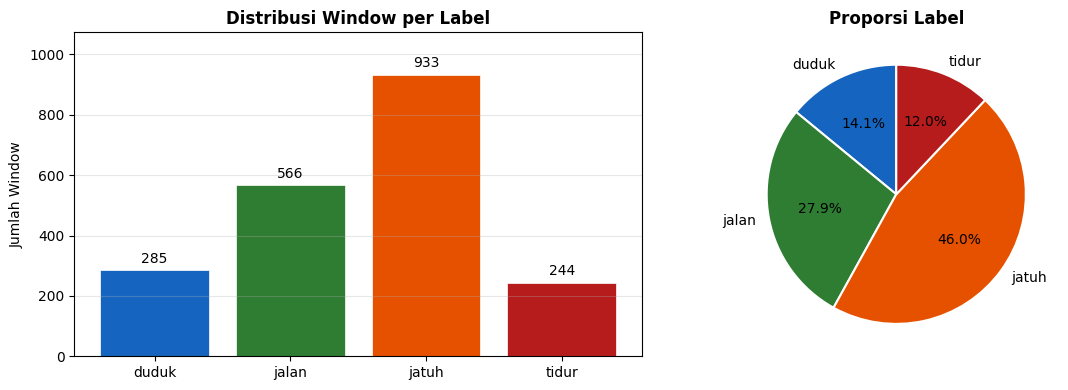

Tersimpan: /content/distribusi_label.png


In [ ]:
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)

print('Mapping label → integer:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

# Plot
labels_s = sorted(win_dist.keys())
counts_s = [win_dist[l] for l in labels_s]
colors4  = ['#1565C0','#2E7D32','#E65100','#B71C1C']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bars = ax1.bar(labels_s, counts_s, color=colors4[:len(labels_s)], edgecolor='white', linewidth=0.5)
ax1.bar_label(bars, padding=3, fontsize=10)
ax1.set_title('Distribusi Window per Label', fontsize=12, fontweight='bold')
ax1.set_ylabel('Jumlah Window')
ax1.set_ylim(0, max(counts_s)*1.15)
ax1.grid(axis='y', alpha=0.3)

ax2.pie(counts_s, labels=labels_s, autopct='%1.1f%%',
        colors=colors4[:len(labels_s)], startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5})
ax2.set_title('Proporsi Label', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/distribusi_label.png', dpi=130)
plt.show()
print('Tersimpan: /content/distribusi_label.png')

## STEP 8 — Visualisasi Sinyal per Label (Sanity Check)

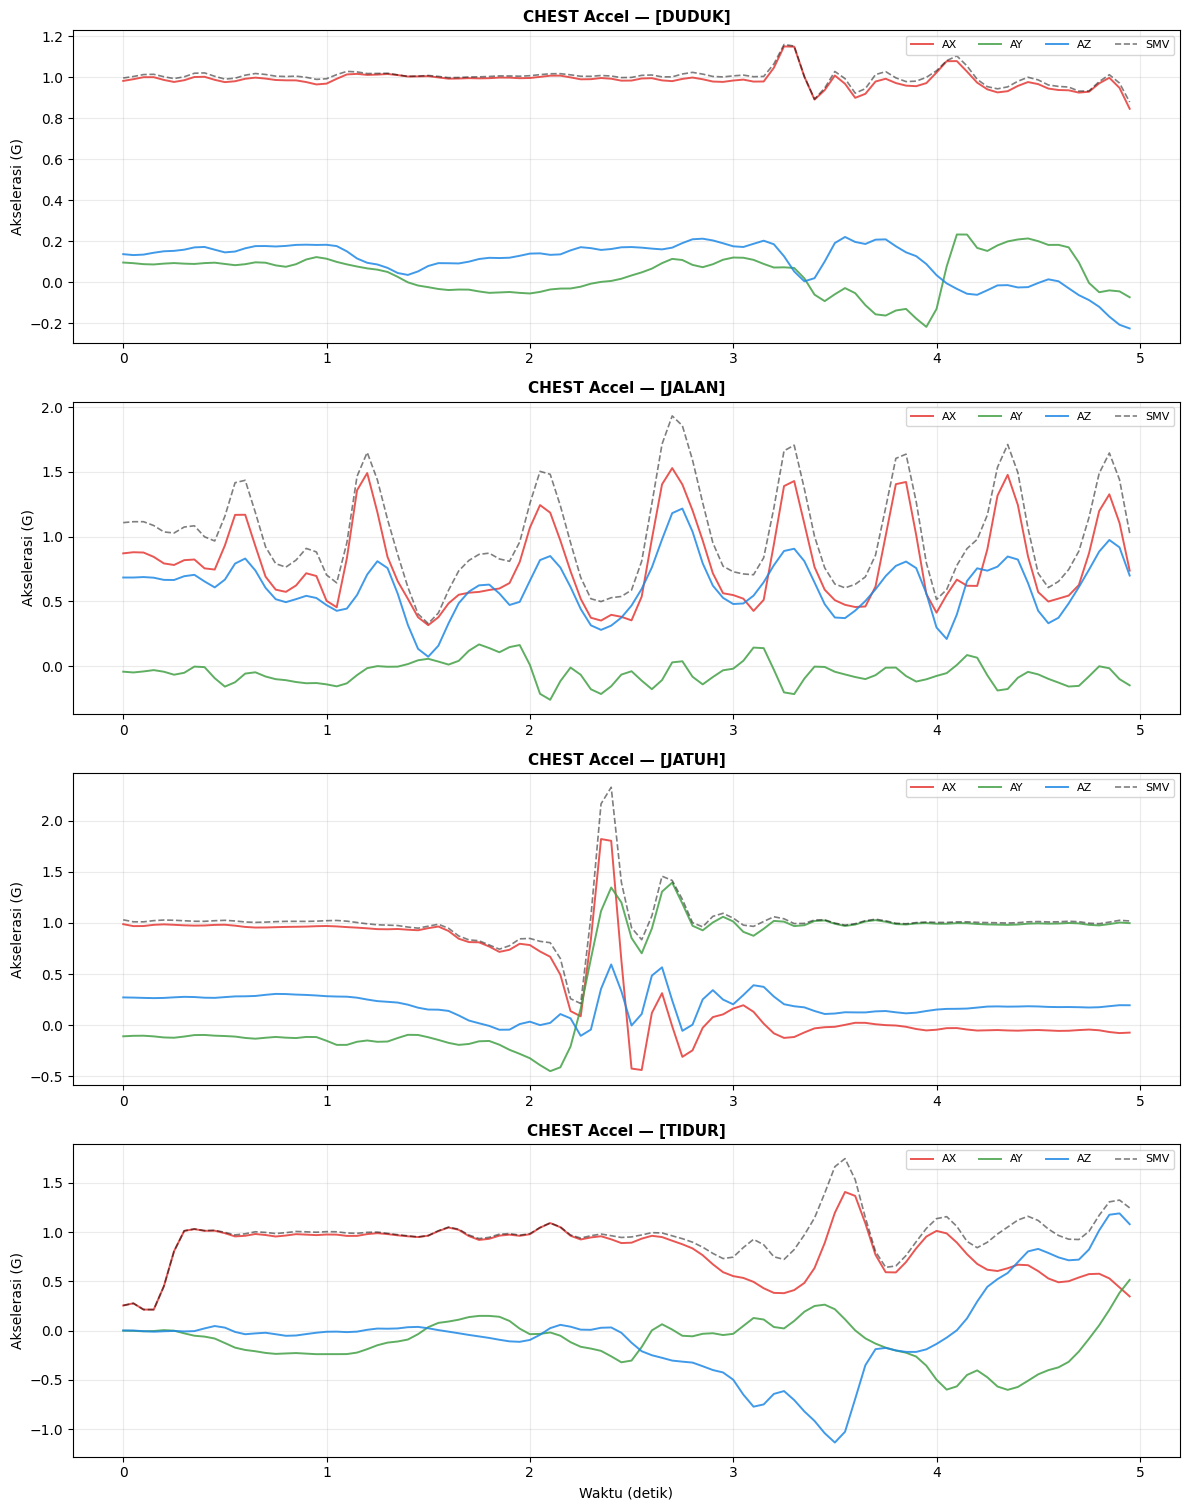

Tersimpan: /content/sinyal_per_label.png


In [ ]:
unique_labels = sorted(set(y_raw))
fig, axes = plt.subplots(len(unique_labels), 1,
                          figsize=(12, 3.8*len(unique_labels)))
if len(unique_labels) == 1:
    axes = [axes]

clr = ['#E53935', '#43A047', '#1E88E5']
for i, lbl in enumerate(unique_labels):
    idx = np.where(y_raw == lbl)[0][0]
    win = X_wins[idx]
    t   = np.arange(len(win)) / FS

    for j in range(3):
        axes[i].plot(t, win[:,j], label=['AX','AY','AZ'][j],
                     color=clr[j], alpha=0.85, lw=1.4)

    smv_plot = np.sqrt(np.sum(win**2, axis=1))
    axes[i].plot(t, smv_plot, label='SMV', color='black',
                 alpha=0.5, lw=1.2, linestyle='--')

    axes[i].set_title(f'CHEST Accel — [{lbl.upper()}]',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Akselerasi (G)')
    axes[i].legend(loc='upper right', fontsize=8, ncol=4)
    axes[i].grid(alpha=0.25)

axes[-1].set_xlabel('Waktu (detik)')
plt.tight_layout()
plt.savefig('/content/sinyal_per_label.png', dpi=130)
plt.show()
print('Tersimpan: /content/sinyal_per_label.png')

## STEP 9 — Simpan Hasil Preprocessing

In [ ]:
SAVE_PATH = '/content/preprocessed_chest.pkl'

with open(SAVE_PATH, 'wb') as f:
    pickle.dump({
        'X'             : X_feat,
        'y'             : y_enc,
        'y_raw'         : y_raw,
        'label_encoder' : le,
        'classes'       : list(le.classes_),
        'window_size'   : WINDOW_SIZE,
        'step_size'     : STEP_SIZE,
        'fs'            : FS,
        'n_features'    : X_feat.shape[1],
    }, f)

print(f'Tersimpan : {SAVE_PATH}')
print(f'X shape   : {X_feat.shape}')
print(f'y shape   : {y_enc.shape}')
print(f'Kelas     : {list(le.classes_)}')

Tersimpan : /content/preprocessed_chest.pkl
X shape   : (2028, 44)
y shape   : (2028,)
Kelas     : [np.str_('duduk'), np.str_('jalan'), np.str_('jatuh'), np.str_('tidur')]


## STEP 10 — Laporan Akhir

In [ ]:
print('='*56)
print('       LAPORAN PREPROCESSING — SELESAI')
print('='*56)
print(f'  File berhasil  : {len(records)}')
print(f'  File dilewati  : {len(skipped_detail)}')
print(f'  Total windows  : {X_feat.shape[0]}')
print(f'  Jumlah fitur   : {X_feat.shape[1]}')
print(f'  Kelas          : {list(le.classes_)}')
print(f'  Window         : {WINDOW_SIZE} sampel = 5s @ {FS}Hz')
print(f'  NaN fixed      : {nan_count}')
print()
print(f'  {"Label":10s}  {"Window":>6s}  {"Pct":>6s}  Distribusi')
print('  ' + '-'*50)
for lbl, cnt in sorted(Counter(y_raw).items()):
    pct = 100*cnt/len(y_raw)
    bar = chr(9608)*int(pct/2)
    print(f'  {lbl:10s}  {cnt:6d}  {pct:5.1f}%  {bar}')
print()
print(f'  Rasio imbalance: {ratio:.1f}x')
print('='*56)
print()
print('KIRIMKAN KE ASISTEN:')
print('  1. Tabel distribusi window di atas')
print('  2. Nilai rasio imbalance')
print('  3. Screenshot /content/sinyal_per_label.png')
print('  → Kita lanjut ke notebook SVM yang optimal')

       LAPORAN PREPROCESSING — SELESAI
  File berhasil  : 460
  File dilewati  : 286
  Total windows  : 2028
  Jumlah fitur   : 44
  Kelas          : [np.str_('duduk'), np.str_('jalan'), np.str_('jatuh'), np.str_('tidur')]
  Window         : 100 sampel = 5s @ 20Hz
  NaN fixed      : 0

  Label       Window     Pct  Distribusi
  --------------------------------------------------
  duduk          285   14.1%  ███████
  jalan          566   27.9%  █████████████
  jatuh          933   46.0%  ███████████████████████
  tidur          244   12.0%  ██████

  Rasio imbalance: 3.8x

KIRIMKAN KE ASISTEN:
  1. Tabel distribusi window di atas
  2. Nilai rasio imbalance
  3. Screenshot /content/sinyal_per_label.png
  → Kita lanjut ke notebook SVM yang optimal


In [ ]:
!cp /content/preprocessed_chest.pkl /content/drive/MyDrive/uma_fall_data/preprocessed_chest.pkl

print('File copied successfully to Google Drive!')

File copied successfully to Google Drive!
